In [27]:
import numpy as np
import pandas as pd
import pickle 
import importlib
import run_omni_wql
importlib.reload(run_omni_wql)
from run_omni_wql import omniprediction_multiq_wql

d = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp_weekly.pkl', 'rb'))
forecasts_dict = d['forecasts_dict']
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
dates_list = d['dates_list']
Y = d['Y']
T = len(dates_list)

print(f_list)
print(alpha_list)
print(dates_list)
print(Y)

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']
[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
Index(['2021-02-23', '2021-03-02', '2021-03-09', '2021-03-16', '2021-03-23',
       '2021-03-30', '2021-04-06', '2021-04-13', '2021-04-20', '2021-04-27',
       ...
       '2023-03-28', '2023-04-04', '2023-04-11', '2023-04-18', '2023-04-25',
       '2023-05-02', '2023-05-09', '2023-05-16', '2023-05-23', '2023-05-30'],
      dtype='str', length=119)
2021-02-23    39206.0
2021-03-02    34961.0
2021-03-09    33410.0
2021-03-16    33334.0
2021-03-23    35409.0
               ...   
2023-05-02     9721.0
2023-05-09     8832.0
2023-05-16     8328.0
2023-05-23     7579.0
2023-05-30     7310.0
Name: actual, Length: 119, dtype: float64


In [29]:
def decimal_to_str(eta):
    return str(np.round(eta, 4)).replace('.', ',')
    
def exp_name_string_wql(w, eta, suffix):
    return f"wk{w}_eta{decimal_to_str(eta)}_{suffix}"

save_folder = 'hosp0315_weekly_wql'
SAVE_DIR = f'../results/{save_folder}'

eta_list = np.round(np.power(10, np.arange(-4, 2.6, 0.5)), 4)
n_seed = 10
for w in range(1, 5):
    print(f"Running wk{w}...")
    for eta_mult in eta_list:
        exp_name = exp_name_string_wql(w, eta_mult, 10)
        results, settings = omniprediction_multiq_wql(Y = d['Y'][d['dates_list']], 
                            forecasts_dict=forecasts_dict[w], 
                            unit=500, 
                            alpha_list=d['alpha_list'], 
                            eta_multiplier=eta_mult, 
                            seed_list=np.arange(1, n_seed+1),  
        )
        pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))


Running wk1...


Eta: 0.1, Seeds:  20%|██        | 2/10 [00:00<00:02,  3.08it/s]

phat is not ordered, max violation: 4.169603325010485e-05
phat is not ordered, max violation: 4.697385692509215e-05
phat is not ordered, max violation: 4.169603325010485e-05
phat is not ordered, max violation: 4.697385692509215e-05


Eta: 0.1, Seeds:  30%|███       | 3/10 [00:01<00:02,  2.93it/s]

phat is not ordered, max violation: 4.169603325010485e-05
phat is not ordered, max violation: 4.697385692509215e-05


...

Eta: 0.1, Seeds:  90%|█████████ | 9/10 [00:03<00:00,  2.90it/s]

phat is not ordered, max violation: 0.0015058808968930748


Eta: 0.1, Seeds: 100%|██████████| 10/10 [00:03<00:00,  2.87it/s]


phat is not ordered, max violation: 0.0015058808968930748


Eta: 316.2278, Seeds: 100%|██████████| 10/10 [00:03<00:00,  2.97it/s]


In [31]:
eta_list = np.round(np.power(10, np.arange(-4, 2.6, 0.5)), 4)
n_seed = 1
for w in range(1, 5):
    print(f"Running wk{w}...")
    for eta_mult in eta_list:
        exp_name = exp_name_string_wql(w, eta_mult, 'settings')
        results, settings = omniprediction_multiq_wql(Y = d['Y'][d['dates_list']], 
                            forecasts_dict=forecasts_dict[w], 
                            unit=500, 
                            alpha_list=d['alpha_list'], 
                            eta_multiplier=eta_mult, 
                            seed_list=np.arange(1, n_seed+1),  
        )
        pickle.dump(settings, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))


Running wk1...


Eta: 0.1, Seeds: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


phat is not ordered, max violation: 4.169603325010485e-05
phat is not ordered, max violation: 4.697385692509215e-05


Eta: 316.2278, Seeds: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]


Running wk2...


...

Eta: 316.2278, Seeds: 100%|██████████| 1/1 [00:00<00:00,  2.59it/s]


Running wk4...


Eta: 0.1, Seeds: 100%|██████████| 1/1 [00:00<00:00,  3.02it/s]


phat is not ordered, max violation: 0.0015058808968930748


Eta: 316.2278, Seeds: 100%|██████████| 1/1 [00:00<00:00,  3.03it/s]


In [36]:
alpha_list

[0.01,
 0.025,
 0.05,
 0.1,
 0.15,
 0.2,
 0.25,
 0.3,
 0.35,
 0.4,
 0.45,
 0.5,
 0.55,
 0.6,
 0.65,
 0.7,
 0.75,
 0.8,
 0.85,
 0.9,
 0.95,
 0.975,
 0.99]

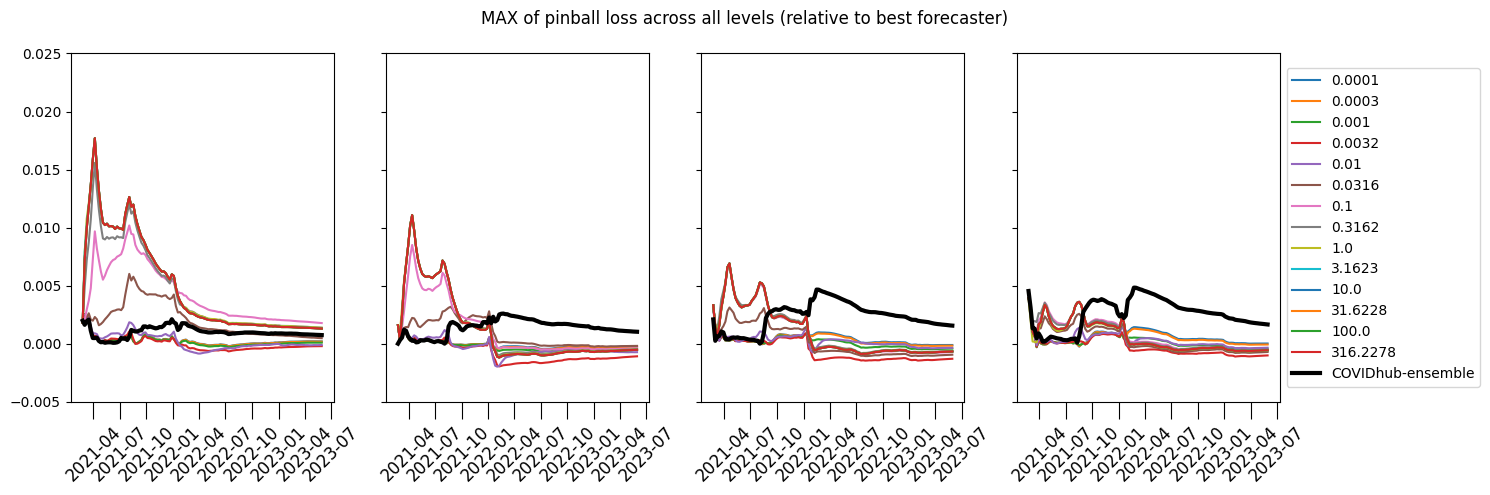

In [63]:
import matplotlib.pyplot as plt
from metrics import pinball_loss


def omni_error_from_pb_loss(pb_loss: np.ndarray):
    # scores: (T, N, ..)
    # return: (T, ..)
    if pb_loss.ndim == 2:
        return np.max(pb_loss.cumsum(axis=0), axis=1) / (np.arange(pb_loss.shape[0]) + 1)
    elif pb_loss.ndim == 3:
        return np.max(pb_loss.cumsum(axis=0), axis=1) / (np.arange(pb_loss.shape[0])[:, None] + 1)
    else:
        raise ValueError(f"scores.ndim: {pb_loss.ndim}")



dates_list = pd.to_datetime(d['dates_list'])
T = len(dates_list)
n_seed = 10

fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharey='row')
for w in range(1,5):
    for eta_mult in eta_list:
        
        exp_name = exp_name_string_wql(w, eta_mult, 10)
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        settings = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_wql(w, eta_mult, 'settings')}.pkl", 'rb'))
        
        omni_rel_trace = np.zeros((T,))
        for seed in range(1, n_seed+1):    
            omni_rel_trace += results[seed]['omni_score_trace_rel']

        ax[w-1].plot(dates_list, omni_rel_trace / n_seed, label=eta_mult)
        
    ens_omni_trace = pinball_loss(results[seed]['forecasters_preds_history'][:,:,-1], settings['y_arr'][:,None], settings['alpha_list'][None, :]) / settings['m']
    ens_omni_rel_trace = omni_error_from_pb_loss(ens_omni_trace) - settings['best_forecaster_score_trace']

    ax[w-1].plot(dates_list, ens_omni_rel_trace, linewidth=3, color='black',label='COVIDhub-ensemble')
    ax[w-1].set_ylim(-0.005, 0.025)
    ax[w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
    if w == 4:
        ax[w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle('MAX of pinball loss across all levels (relative to best forecaster)')
fig.tight_layout()
plt.show()


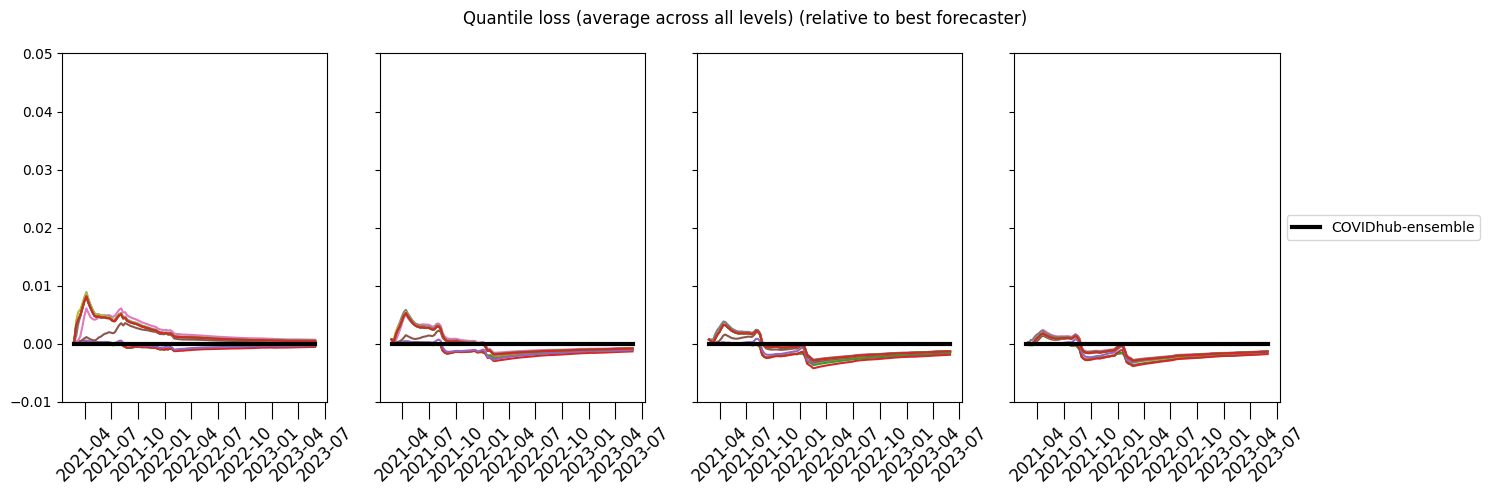

In [ ]:
import matplotlib.pyplot as plt
from metrics import pinball_loss


def ql_error_from_pb_loss(pb_loss: np.ndarray):
    # scores: (T, N, ..)
    # return: (T, ..)
    if pb_loss.ndim == 2:
        return np.average(pb_loss.cumsum(axis=0), axis=1) / (np.arange(pb_loss.shape[0]) + 1)
    elif pb_loss.ndim == 3:
        return np.average(pb_loss.cumsum(axis=0), axis=1) / (np.arange(pb_loss.shape[0])[:, None] + 1)
    else:
        raise ValueError(f"scores.ndim: {pb_loss.ndim}")



dates_list = pd.to_datetime(d['dates_list'])
T = len(dates_list)
n_seed = 10

fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharey='row')
for w in range(1,5):
    for eta_mult in eta_list:
        
        exp_name = exp_name_string_wql(w, eta_mult, 10)
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        settings = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_wql(w, eta_mult, 'settings')}.pkl", 'rb'))
        
        ens_omni_trace = pinball_loss(results[seed]['forecasters_preds_history'][:,:,-1], settings['y_arr'][:,None], settings['alpha_list'][None, :]) / settings['m']
        ens_omni_rel_trace = ql_error_from_pb_loss(ens_omni_trace) - ql_error_from_pb_loss(pinball_loss(results[seed]['forecasters_preds_history'][:,:,-1], settings['y_arr'][:,None], settings['alpha_list'][None, :]) / settings['m'])
    
        omni_rel_trace = np.zeros((T,))
        for seed in range(1, n_seed+1):    
            omni_rel_trace += ql_error_from_pb_loss(results[seed]['omni_pb_loss_history'])

        ax[w-1].plot(dates_list, (omni_rel_trace / n_seed - ql_error_from_pb_loss(pinball_loss(results[seed]['forecasters_preds_history'][:,:,-1], settings['y_arr'][:,None], settings['alpha_list'][None, :]) / settings['m'])))
        

    ax[w-1].plot(dates_list, ens_omni_rel_trace, linewidth=3, color='black',label='COVIDhub-ensemble')
    ax[w-1].set_ylim(-0.005, 0.025)
    ax[w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
    if w == 4:
        ax[w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle('Quantile loss (average across all levels) (relative to best forecaster)')
fig.tight_layout()
plt.show()